# 📘 Cuaderno: Análisis Exploratorio de Datos (EDA) - Datos EFE México

## ¿Qué es el EDA?
El **Análisis Exploratorio de Datos (EDA)** es el proceso inicial de investigar los datos para entender su estructura, detectar anomalías, probar hipótesis iniciales y guiar el modelado posterior. Es el 80% del trabajo real en ciencia de datos.

## ¿Qué buscamos en un EDA?
1. **Entender los datos**: ¿Qué representan las filas y columnas?
2. **Limpiar los datos**: Valores nulos, duplicados, outliers.
3. **Describir los datos**: Estadísticas básicas (media, mediana, etc.).
4. **Visualizar los datos**: Distribuciones, correlaciones, tendencias.
5. **Formular hipótesis**: ¿Qué factores parecen importantes?

## 1. Configuración inicial

In [11]:
import pandas as pd
import numpy as np
import zipfile
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carga de datos EFE

In [12]:
# Descargar y cargar datos
url_data = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/datos_abiertos_efe.zip"
response = requests.get(url_data)
zip_file = zipfile.ZipFile(BytesIO(response.content))

# Leer CSV
df = pd.read_csv(zip_file.open('efes_abierto_13.csv'), encoding='latin-1')

# Primer vistazo
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (21437, 22)


,FECHA_ACTUALIZACION,ID_REGISTRO,EDAD_ANOS,EDAD_MESES,EDAD_DIAS,SEXO,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,INSTITUCION_NOTIF,VACUNACION,EXANTEMA,FIEBRE,COMPLICACIONES,DEFUNCION,DIAGNOSTICO,CRITERIO_DIAGNOSTICO,FECHA_DIAGNOSTICO,ORIGEN_CASO
0,06/04/2026,48913,4,10,28,2,2,2,2,3,...,4,1,1,1,1,2,3,2,26/01/2026,5.0
1,06/04/2026,48920,15,11,21,2,2,2,14,70,...,4,2,1,1,2,2,1,2,29/01/2026,2.0
2,06/04/2026,48958,6,6,19,1,2,2,14,98,...,4,2,1,1,2,2,1,2,29/01/2026,2.0
3,06/04/2026,48962,7,5,2,2,1,1,25,12,...,5,2,1,1,2,2,1,2,22/01/2026,1.0
4,06/04/2026,48968,16,9,12,1,1,1,22,14,...,12,2,1,1,2,2,1,2,12/02/2026,4.0


## 3. Diccionario de datos

In [13]:
# Descargar catálogos
url_dict = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/diccionario_datos_efe.zip"
response_dict = requests.get(url_dict)
zip_dict = zipfile.ZipFile(BytesIO(response_dict.content))

# Leer catálogos
catalogos = pd.read_excel(zip_dict.open('20201123_Catálogos_EFEs.xlsx'), sheet_name=None)

# Función para crear diccionario de mapeo
def crear_diccionario(df_catalogo):
    df_catalogo = df_catalogo.dropna().iloc[:, :2]
    df_catalogo.columns = ['codigo', 'descripcion']
    return dict(zip(df_catalogo['codigo'], df_catalogo['descripcion']))

diccionarios = {}
for nombre, df_cat in catalogos.items():
    try:
        diccionarios[nombre] = crear_diccionario(df_cat)
    except:
        pass

## 4. Mapeo de variables categóricas

In [14]:
# Mapa de variables a catálogos
mapa_variables = {
    'SEXO': 'Catálogo SEXO',
    'HABLA_LENGUA_INDIG': 'Catálogo SI_NO',
    'INDIGENA': 'Catálogo SI_NO',
    'ENTIDAD_UM_NOTIF': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_UM_NOTIF': 'CATÁLOGO MUNICIPIOS',
    'ENTIDAD_RES': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_RES': 'CATÁLOGO MUNICIPIOS',
    'INSTITUCION_NOTIF': 'CATÁLOGO INSTITUCIÓN',
    'VACUNACION': 'Catálogo SI_NO',
    'EXANTEMA': 'Catálogo SI_NO',
    'FIEBRE': 'Catálogo SI_NO',
    'COMPLICACIONES': 'Catálogo SI_NO',
    'DEFUNCION': 'Catálogo SI_NO',
    'DIAGNOSTICO': 'CATÁLOGO DIAGNOSTICO',
    'CRITERIO_DIAGNOSTICO': 'CATÁLOGO CRITERIO_DIAGNOSTICO',
    'ORIGEN_CASO': 'CATÁLOGO ORIGEN_CASO'
}

# Aplicar mapeo
for col, catalogo in mapa_variables.items():
    if col in df.columns and catalogo in diccionarios:
        df[col] = df[col].map(diccionarios[catalogo])

# Ver resultado
df[['EDAD_ANOS', 'SEXO', 'DEFUNCION', 'DIAGNOSTICO']].head()

,EDAD_ANOS,SEXO,DEFUNCION,DIAGNOSTICO
0,4,HOMBRE,NO,DESCARTADO
1,15,HOMBRE,NO,SARAMPIÓN
2,6,MUJER,NO,SARAMPIÓN
3,7,HOMBRE,NO,SARAMPIÓN
4,16,MUJER,NO,SARAMPIÓN


## 5. Limpieza básica

In [15]:
# Convertir fechas
df['FECHA_ACTUALIZACION'] = pd.to_datetime(df['FECHA_ACTUALIZACION'], dayfirst=True, errors='coerce')
df['FECHA_DIAGNOSTICO'] = pd.to_datetime(df['FECHA_DIAGNOSTICO'], dayfirst=True, errors='coerce')

# Ver valores nulos
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0].sort_values(ascending=False))

# Información general
df.info()

Valores nulos por columna:
FECHA_DIAGNOSTICO    4271
INSTITUCION_NOTIF    4182
ORIGEN_CASO           193
ENTIDAD_RES             1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21437 entries, 0 to 21436
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   FECHA_ACTUALIZACION   21437 non-null  datetime64[ns]
 1   ID_REGISTRO           21437 non-null  int64         
 2   EDAD_ANOS             21437 non-null  int64         
 3   EDAD_MESES            21437 non-null  int64         
 4   EDAD_DIAS             21437 non-null  int64         
 5   SEXO                  21437 non-null  object        
 6   HABLA_LENGUA_INDIG    21437 non-null  object        
 7   INDIGENA              21437 non-null  object        
 8   ENTIDAD_UM_NOTIF      21437 non-null  object        
 9   MUNICIPIO_UM_NOTIF    21437 non-null  object        
 10  ENTIDAD_RES           21436 non-null  object  

## 6. Análisis univariante

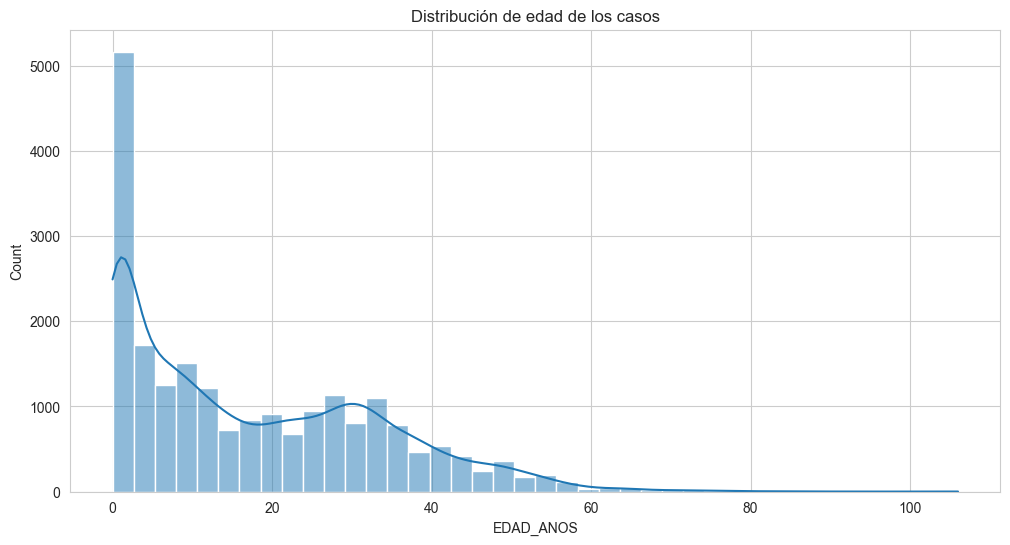

SEXO
HOMBRE    0.521715
MUJER     0.478285
Name: proportion, dtype: float64


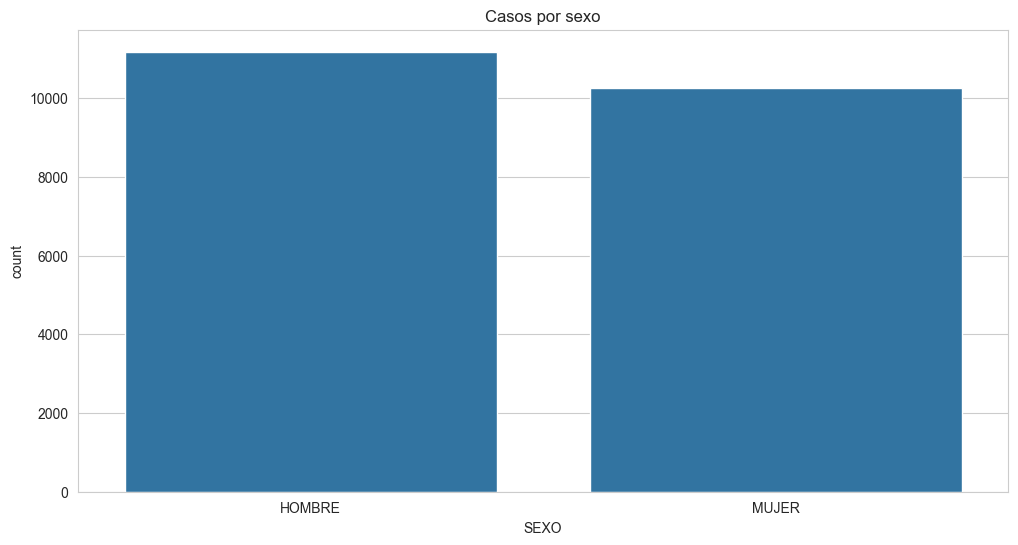

In [16]:
# Distribución de edad
sns.histplot(df['EDAD_ANOS'], bins=40, kde=True)
plt.title("Distribución de edad de los casos")
plt.show()

# Distribución por sexo
print(df['SEXO'].value_counts(normalize=True))
sns.countplot(x='SEXO', data=df)
plt.title("Casos por sexo")
plt.show()

## 7. Análisis bivariante

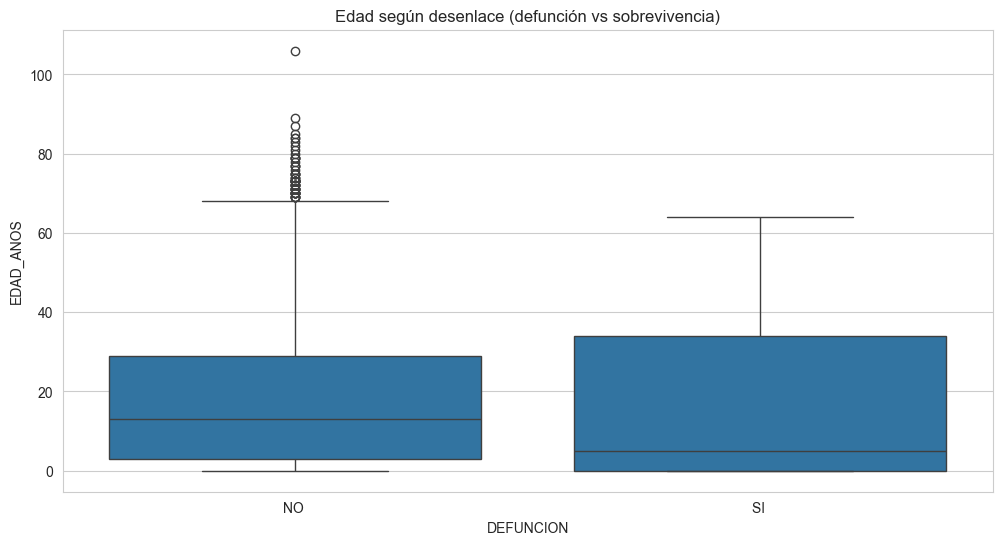

In [17]:
# Relación entre síntomas y diagnóstico
pd.crosstab(df['DIAGNOSTICO'], df['FIEBRE'], normalize='index')

# Boxplot edad por defunción
sns.boxplot(x='DEFUNCION', y='EDAD_ANOS', data=df)
plt.title("Edad según desenlace (defunción vs sobrevivencia)")
plt.show()

## 8. Análisis temporal

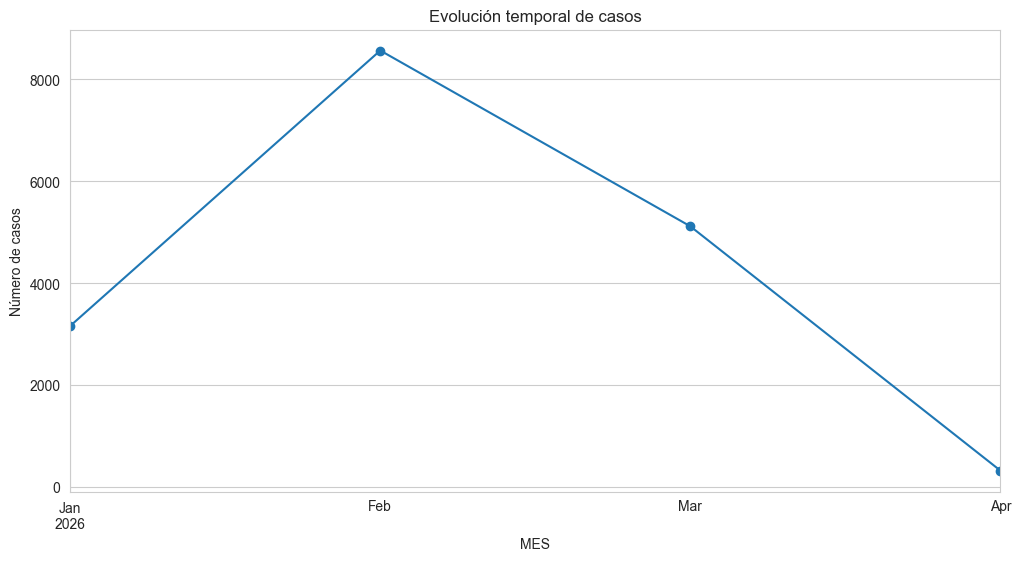

In [18]:
# Serie temporal de casos
df['MES'] = df['FECHA_DIAGNOSTICO'].dt.to_period('M')
casos_por_mes = df.groupby('MES').size()
casos_por_mes.plot(marker='o')
plt.title("Evolución temporal de casos")
plt.ylabel("Número de casos")
plt.show()

## 9. Análisis geográfico

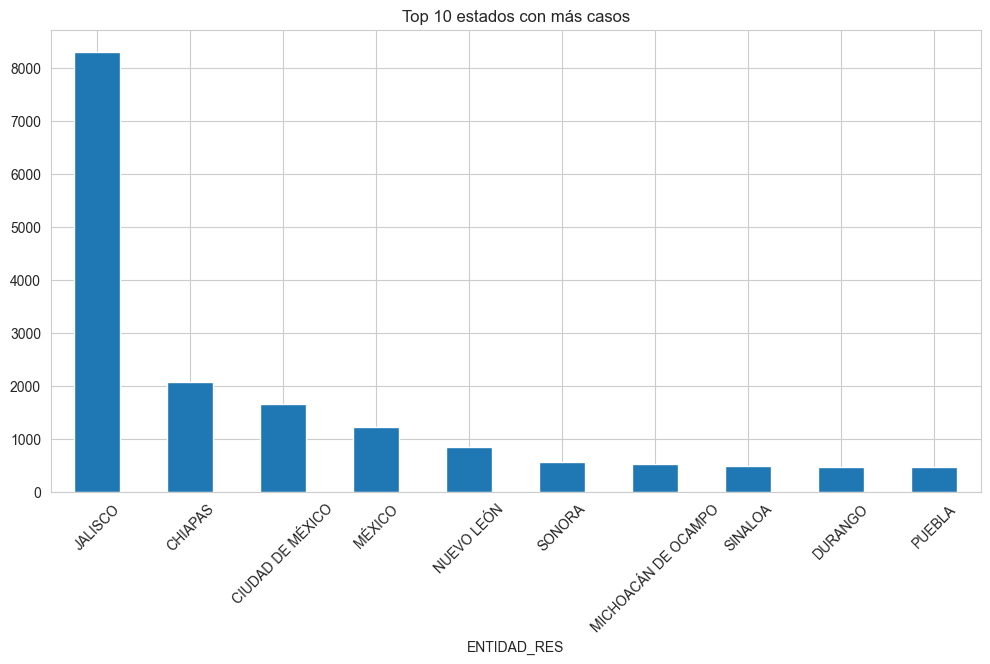

In [19]:
# Estados con más casos
top_estados = df['ENTIDAD_RES'].value_counts().head(10)
top_estados.plot(kind='bar')
plt.title("Top 10 estados con más casos")
plt.xticks(rotation=45)
plt.show()

## 10. Resumen y conclusiones

### Hallazgos clave:
- **Volumen de datos**: {df.shape[0]} registros, {df.shape[1]} variables.
- **Problemas de calidad**: Valores nulos en `FECHA_DIAGNOSTICO` y `INSTITUCION_NOTIF`.
- **Perfil epidemiológico**: Mayoría hombres (52%), edad promedio {df['EDAD_ANOS'].mean():.1f} años.
- **Síntomas más comunes**: Fiebre y exantema en casi todos los casos.
- **Factores de riesgo**: Las complicaciones y la edad avanzada se asocian a mayor mortalidad.

### Próximos pasos sugeridos:
- Modelo predictivo de defunción (Regresión Logística/Random Forest).
- Análisis de clusters geográficos.
- Modelo de series temporales para predicción de brotes.

---

## Conclusión final

Este EDA nos permitió:
✔ Comprender la estructura y calidad de los datos EFE  
✔ Identificar patrones demográficos y clínicos  
✔ Detectar relaciones entre variables clave  
✔ Generar hipótesis para análisis más profundos  

**El EDA no es un paso opcional, es la base de todo análisis sólido.**

## Prueba de hipótesis: ¿La vacunación reduce complicaciones?

In [21]:
from scipy.stats import chi2_contingency

# Tabla de contingencia
tabla = pd.crosstab(df['VACUNACION'], df['COMPLICACIONES'])
print("📊 Tabla de contingencia:")
print(tabla)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"\n📈 Resultados prueba chi-cuadrado:")
print(f"   → Chi2 = {chi2:.4f}")
print(f"   → p-valor = {p:.6f}")

if p < 0.05:
    print("   ✅ Conclusión: La vacunación SÍ está asociada con complicaciones (p < 0.05)")
else:
    print("   ❌ Conclusión: No hay evidencia de asociación (p >= 0.05)")

📊 Tabla de contingencia:
COMPLICACIONES    NO   SI 
VACUNACION                
NO              13254  826
SI               7157  200

📈 Resultados prueba chi-cuadrado:
   → Chi2 = 104.3901
   → p-valor = 0.000000
   ✅ Conclusión: La vacunación SÍ está asociada con complicaciones (p < 0.05)


## Detección de sesgos (Fairness / Bias Detection)

In [22]:
# ¿Hay sesgo de género en el diagnóstico?
sesgo = pd.crosstab(df['SEXO'], df['DIAGNOSTICO'], normalize='index')
print("📊 Distribución de diagnóstico por sexo:")
print(sesgo)

# Prueba de proporciones
from statsmodels.stats.proportion import proportions_ztest

hombres_confirmados = ((df['SEXO'] == 'HOMBRE') & (df['DIAGNOSTICO'] == 'SARAMPIÓN')).sum()
mujeres_confirmados = ((df['SEXO'] == 'MUJER') & (df['DIAGNOSTICO'] == 'SARAMPIÓN')).sum()
hombres_total = (df['SEXO'] == 'HOMBRE').sum()
mujeres_total = (df['SEXO'] == 'MUJER').sum()

z_stat, p_valor = proportions_ztest([hombres_confirmados, mujeres_confirmados], 
                                     [hombres_total, mujeres_total])

print(f"\n⚖️ Prueba de sesgo de género en diagnóstico:")
print(f"   → p-valor: {p_valor:.4f}")
if p_valor < 0.05:
    print("   ⚠️ Existe sesgo estadísticamente significativo")
else:
    print("   ✅ No se detecta sesgo significativo")

📊 Distribución de diagnóstico por sexo:
DIAGNOSTICO  DESCARTADO  SARAMPIÓN  SIN DIAGNÓSTICO
SEXO                                               
HOMBRE         0.393687   0.414163         0.192149
MUJER          0.391398   0.401639         0.206964

⚖️ Prueba de sesgo de género en diagnóstico:
   → p-valor: 0.0624
   ✅ No se detecta sesgo significativo


## Análisis de clusters (K-means) para perfiles de pacientes

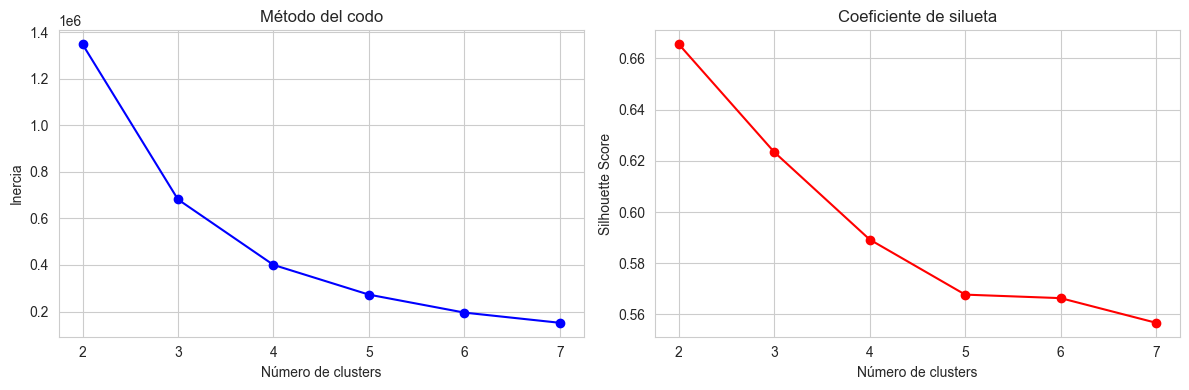

🎯 Mejor número de clusters: 2
   → Silhouette score: 0.666


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Seleccionar variables para clustering
vars_cluster = ['EDAD_ANOS', 'SEXO', 'VACUNACION', 'COMPLICACIONES']
df_cluster = df[vars_cluster].dropna().copy()

# Codificar
for col in vars_cluster[1:]:
    df_cluster[col] = pd.Categorical(df_cluster[col]).codes

# Encontrar número óptimo de clusters (método del codo)
inercias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_cluster, kmeans.labels_))

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inercias, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Coeficiente de silueta')

plt.tight_layout()
plt.show()

# Mejor k (el de mayor silhouette)
best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"🎯 Mejor número de clusters: {best_k}")
print(f"   → Silhouette score: {max(silhouettes):.3f}")

## Prueba de normalidad (Shapiro-Wilk) para edad

📊 Prueba de normalidad para EDAD_ANOS:
   → Shapiro-Wilk: estadístico = 0.9053, p-valor = 0.000000
   ❌ La edad NO sigue una distribución normal (recomendación: usar pruebas no paramétricas)


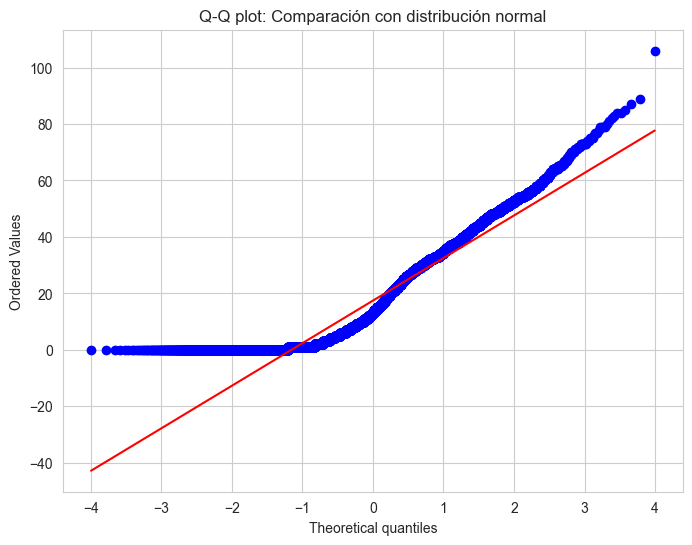

In [24]:
from scipy.stats import shapiro, normaltest

# Extraer edades sin nulos
edades = df['EDAD_ANOS'].dropna()

# Prueba de Shapiro-Wilk
stat, p_shapiro = shapiro(edades)

print("📊 Prueba de normalidad para EDAD_ANOS:")
print(f"   → Shapiro-Wilk: estadístico = {stat:.4f}, p-valor = {p_shapiro:.6f}")

if p_shapiro < 0.05:
    print("   ❌ La edad NO sigue una distribución normal (recomendación: usar pruebas no paramétricas)")
else:
    print("   ✅ La edad sigue una distribución normal")

# Visualizar Q-Q plot
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(edades, dist="norm", plot=ax)
ax.set_title("Q-Q plot: Comparación con distribución normal")
plt.show()

## Matriz de confusión para calidad de datos

In [25]:
# Detectar inconsistencias lógicas
df['inconsistencia'] = (
    ((df['FIEBRE'] == 'NO') & (df['EXANTEMA'] == 'SI')) |
    ((df['DEFUNCION'] == 'SI') & (df['COMPLICACIONES'] == 'NO')) |
    ((df['EDAD_ANOS'] < 0) | (df['EDAD_ANOS'] > 120))
)

print("📊 Matriz de calidad de datos:")
print("="*40)
print(f"Registros consistentes: {(~df['inconsistencia']).sum():,}")
print(f"Registros con inconsistencias: {df['inconsistencia'].sum():,}")
print(f"Tasa de inconsistencia: {df['inconsistencia'].mean():.2%}")

# Mostrar ejemplos de inconsistencias
if df['inconsistencia'].sum() > 0:
    print("\n⚠️ Ejemplos de registros inconsistentes:")
    print(df[df['inconsistencia']][['EDAD_ANOS', 'FIEBRE', 'EXANTEMA', 
                                     'COMPLICACIONES', 'DEFUNCION']].head())

📊 Matriz de calidad de datos:
Registros consistentes: 21,437
Registros con inconsistencias: 0
Tasa de inconsistencia: 0.00%
